# 08 — Model Training & Comparison

Train a baseline and three classifiers — Logistic Regression, Decision
Tree, Random Forest — to predict `high_crime_day`. Check result
stability with temporal cross-validation, tune Random Forest, and
evaluate the selected model on the chronological test set.

**Inputs.** `data/processed/modeling_dataset.parquet`,
`data/processed/feature_metadata.csv` (notebook 07 output).

**Outputs.** `models/{logistic_regression,decision_tree,random_forest}.joblib`,
`outputs/tables/model_comparison.csv`, `outputs/tables/cv_summary.csv`.

**Methodology**
- Cross-validation uses date-based `TimeSeriesSplit` folds — never a
  random split — so no fold trains on data from after its own
  validation period.
- The test set (2024–2025) is evaluated once, after model selection is
  final, and never used to choose between models.
- Every evaluation reports accuracy alongside precision, recall, F1,
  ROC-AUC, and PR-AUC — accuracy alone is misleading on an imbalanced
  target.
- Class imbalance is handled with `class_weight="balanced"`; resampling
  (SMOTE) is not applied unless the results below show weighting alone
  is insufficient.
- Feature importance and error analysis are covered in notebook 09, to
  keep this notebook focused on training and comparison.


## 02 — Environment & Imports

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, classification_report,
)

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 130)

from src import config

RANDOM_STATE = config.RANDOM_STATE

DATASET_PATH = config.DATA_PROCESSED / "modeling_dataset.parquet"
METADATA_PATH = config.DATA_PROCESSED / "feature_metadata.csv"
MODELS_DIR = config.MODELS_DIR
TABLE_DIR = config.OUTPUTS_DIR / "tables"
FIG_DIR = config.OUTPUTS_DIR / "figures" / "modeling"
for d in [MODELS_DIR, TABLE_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

## 03 — Load & Validate

Loads notebook 07's output and stops with a clear error if either file
is missing, rather than proceeding on incomplete data. The feature list
comes from `feature_metadata.csv` — the same list notebook 07 finalized —
so the two notebooks can never drift out of sync.

In [2]:
for path, producer in [(DATASET_PATH, "07_model_dataset_creation"), (METADATA_PATH, "07_model_dataset_creation")]:
    if not path.exists():
        raise FileNotFoundError(f"{path} not found. Run {producer}.ipynb first.")

df = pd.read_parquet(DATASET_PATH)
feature_metadata_df = pd.read_csv(METADATA_PATH)
df["date"] = pd.to_datetime(df["date"])

FEATURE_COLS = feature_metadata_df.loc[feature_metadata_df["column"] != "high_crime_day", "column"].tolist()
print(f"dataset: {df.shape}   features from feature_metadata.csv: {len(FEATURE_COLS)}")
assert all(c in df.columns for c in FEATURE_COLS), "feature_metadata.csv references a column not present in the dataset"
assert "high_crime_day" in df.columns
assert df["split"].isin(["train", "validation", "test"]).all()
assert df[FEATURE_COLS + ["high_crime_day"]].isna().sum().sum() == 0
print("Validated: feature list matches dataset columns, no missing values, split labels well-formed.")

dataset: (138446, 32)   features from feature_metadata.csv: 28
Validated: feature list matches dataset columns, no missing values, split labels well-formed.


Row counts per split, for reference against the class-balance figures in Section 05.

In [3]:
df["split"].value_counts().loc[["train", "validation", "test"]]

split
train         54054
validation    28105
test          56287
Name: count, dtype: int64

## 04 — Feature Matrix Preparation

`season` is one-hot encoded (`drop_first=True`, avoiding redundant
columns for Logistic Regression). Boolean flag columns are cast to
integers. `community_area` and `date` are identifiers only, not model
inputs — each area's own history is already captured through its
lag/rolling features, so a raw area ID would be redundant.

Two versions of the feature matrix are built: unscaled, for Decision
Tree and Random Forest (scale has no effect on tree splits), and scaled,
for Logistic Regression — the scaler is fit on the training split only
and applied unchanged to validation and test, so no information from
later periods informs the scaling.

In [4]:
BOOL_COLS = [c for c in FEATURE_COLS if df[c].dtype == bool]
for c in BOOL_COLS:
    df[c] = df[c].astype(int)

df_encoded = pd.get_dummies(df, columns=["season"], drop_first=True)
SEASON_DUMMY_COLS = [c for c in df_encoded.columns if c.startswith("season_")]
MODEL_FEATURE_COLS = [c for c in FEATURE_COLS if c != "season"] + SEASON_DUMMY_COLS

print(f"model feature count: {len(MODEL_FEATURE_COLS)} (season -> {len(SEASON_DUMMY_COLS)} dummies)")
MODEL_FEATURE_COLS

model feature count: 30 (season -> 3 dummies)


['year',
 'month',
 'day_of_week',
 'week_of_year',
 'quarter',
 'is_weekend',
 'avg_temp',
 'temp_range',
 'PRCP',
 'SNOW',
 'AWND',
 'is_rain',
 'is_snow',
 'is_heavy_rain',
 'is_heavy_snow',
 'is_extreme_heat',
 'is_extreme_cold',
 'crime_count_lag_1',
 'crime_count_lag_3',
 'crime_count_lag_7',
 'crime_count_lag_14',
 'crime_count_lag_28',
 'crime_rolling_7',
 'crime_rolling_14',
 'crime_rolling_28',
 'recent_7d_avg',
 'previous_7d_avg',
 'season_Spring',
 'season_Summer',
 'season_Winter']

In [5]:
def split_xy(split_name):
    mask = df_encoded["split"] == split_name
    X = df_encoded.loc[mask, MODEL_FEATURE_COLS].reset_index(drop=True)
    y = df_encoded.loc[mask, "high_crime_day"].reset_index(drop=True)
    dates = df_encoded.loc[mask, "date"].reset_index(drop=True)
    return X, y, dates

X_train, y_train, dates_train = split_xy("train")
X_val, y_val, dates_val = split_xy("validation")
X_test, y_test, dates_test = split_xy("test")

print(f"train: {X_train.shape}   validation: {X_val.shape}   test: {X_test.shape}")
print("X_test / y_test are loaded now for convenience only -- not evaluated until Section 13.")

train: (54054, 30)   validation: (28105, 30)   test: (56287, 30)
X_test / y_test are loaded now for convenience only -- not evaluated until Section 13.


In [6]:
scaler = StandardScaler().fit(X_train)  # fit on train only
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=MODEL_FEATURE_COLS)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=MODEL_FEATURE_COLS)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=MODEL_FEATURE_COLS)
print("Scaler fit on X_train only; applied unchanged to validation/test.")

Scaler fit on X_train only; applied unchanged to validation/test.


## 05 — Class Balance Recap

Restated from notebook 07, because it directly sets this section's
modeling decision.

In [7]:
balance = df.groupby("split")["high_crime_day"].agg(["mean", "count"]).loc[["train", "validation", "test"]]
balance.columns = ["positive_rate", "n_rows"]
balance

,positive_rate,n_rows
split,,
train,0.207034,54054
validation,0.324462,28105
test,0.278181,56287


**Decision.** The minority-class (`high_crime_day=1`) rate runs
21%–32% across splits — moderate imbalance, not severe. `class_weight="balanced"`
is applied to every model below as the primary correction;
resampling is not introduced unless the results that follow show
weighting alone isn't enough.

## 06 — Metrics Utilities

One evaluation function, used identically for every model, so results
are directly comparable. Accuracy is always computed alongside
precision, recall, F1, ROC-AUC, and PR-AUC.

In [8]:
def compute_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }

comparison_records = []

def evaluate(model, X, y, model_name, split_name, record=True):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    metrics = compute_metrics(y, y_pred, y_proba)
    if record:
        comparison_records.append({"model": model_name, "split": split_name, **metrics})
    return metrics

## 07 — Baseline: `DummyClassifier`

Always predicts the majority class (`high_crime_day=0`). This sets the
floor every real model needs to beat — a model that can't outperform
this isn't adding value. On the positive class, precision/recall/F1 are
expected to be exactly 0 (it never predicts 1) and ROC-AUC exactly 0.5
(a constant score carries no discrimination) — this is the expected
result, not a partial failure.

In [9]:
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)

baseline_val_metrics = evaluate(baseline, X_val, y_val, "Baseline (Dummy)", "validation")
baseline_val_metrics

{'accuracy': 0.6755381604696673,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': 0.5,
 'pr_auc': 0.3244618395303327}

Confirms the expected floor: zero positive-class detection, ROC-AUC at chance level, by construction.

## 08 — Logistic Regression

`class_weight="balanced"` and the scaled features from Section 04;
`max_iter` is raised to ensure convergence.

In [10]:
log_reg = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

log_reg_val_metrics = evaluate(log_reg, X_val_scaled, y_val, "Logistic Regression", "validation")
log_reg_val_metrics

{'accuracy': 0.3471980074719801,
 'precision': 0.32889564636950236,
 'recall': 0.9725847132361004,
 'f1': 0.4915615906886518,
 'roc_auc': 0.5824855772719078,
 'pr_auc': 0.39677218286308263}

Recorded for comparison in Section 11 alongside Decision Tree and Random Forest.

## 09 — Decision Tree (nonlinear baseline)

A second, nonlinear baseline — kept intentionally shallow
(`max_depth=10`, `min_samples_leaf=20`) rather than grown to full depth,
which would fit the training set closely and generalize poorly.
Random Forest is where the real tuning effort goes (Section 13).

In [11]:
dec_tree = DecisionTreeClassifier(
    max_depth=10, min_samples_leaf=20, class_weight="balanced", random_state=RANDOM_STATE,
)
dec_tree.fit(X_train, y_train)

dec_tree_val_metrics = evaluate(dec_tree, X_val, y_val, "Decision Tree", "validation")
dec_tree_val_metrics

{'accuracy': 0.4978117772638321,
 'precision': 0.3563912368466448,
 'recall': 0.6796797894505977,
 'f1': 0.4675971331572991,
 'roc_auc': 0.5640051008317093,
 'pr_auc': 0.3763558405210737}

Recorded for comparison in Section 11.

## 10 — Random Forest (default)

Untuned, standard settings — the reference point Section 13's tuned
version is measured against.

In [12]:
rf_default = RandomForestClassifier(
    n_estimators=200, max_depth=15, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf_default.fit(X_train, y_train)

rf_default_val_metrics = evaluate(rf_default, X_val, y_val, "Random Forest (default)", "validation")
rf_default_val_metrics

{'accuracy': 0.5731008717310088,
 'precision': 0.3751192851565889,
 'recall': 0.4741747998684066,
 'f1': 0.4188704833866124,
 'roc_auc': 0.5708153924881965,
 'pr_auc': 0.39075686148487565}

Recorded for comparison in Section 11 — and, more importantly, in Section 12's cross-validation.

## 11 — Single-Split Comparison (before CV/tuning)

In [13]:
single_split_df = pd.DataFrame(comparison_records).set_index("model")[
    ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
].round(3)
single_split_df

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Baseline (Dummy),0.676,0.000,0.000,0.000,0.500,0.324
Logistic Regression,0.347,0.329,0.973,0.492,0.582,0.397
Decision Tree,0.498,0.356,0.680,0.468,0.564,0.376
Random Forest (default),0.573,0.375,0.474,0.419,0.571,0.391


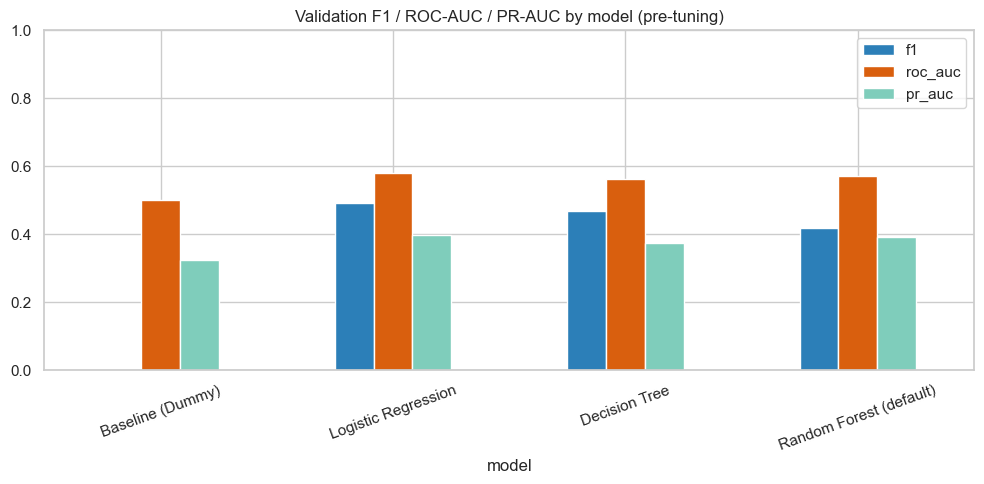

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
single_split_df[["f1", "roc_auc", "pr_auc"]].plot(kind="bar", ax=ax, color=["#2c7fb8", "#d95f0e", "#7fcdbb"])
ax.set_title("Validation F1 / ROC-AUC / PR-AUC by model (pre-tuning)")
ax.set_ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Reading.** By F1 on this single split: Logistic Regression 0.492 >
Decision Tree 0.468 > Random Forest (default) 0.419 > Baseline 0.000.

This ranking needs a second look before it's trusted: Logistic
Regression's F1 is driven by recall of 0.973 against precision of only
0.329 — it is close to predicting positive for nearly every row, which
mechanically inflates recall and F1 on an imbalanced target without
necessarily reflecting real discriminative skill. Section 12's
cross-validation is the actual test of whether this ranking holds.

## 12 — Temporal Cross-Validation

`TimeSeriesSplit` is applied to unique calendar dates, not row index.
Each date has 77 community-area rows, so splitting on row index could
cut a single date's rows across a fold boundary. Splitting on date
first and mapping back to rows keeps every fold's training window
strictly before its validation window, with no date split across the
two.

In [15]:
def make_chronological_folds(dates_series, n_splits):
    unique_dates = np.sort(dates_series.unique())
    tscv = TimeSeriesSplit(n_splits=n_splits)
    folds = []
    for train_date_idx, val_date_idx in tscv.split(unique_dates):
        train_dates = set(unique_dates[train_date_idx])
        val_dates = set(unique_dates[val_date_idx])
        train_rows = dates_series[dates_series.isin(train_dates)].index.to_numpy()
        val_rows = dates_series[dates_series.isin(val_dates)].index.to_numpy()
        folds.append((train_rows, val_rows))
    return folds

N_CV_SPLITS = 5
cv_folds = make_chronological_folds(dates_train, N_CV_SPLITS)
for i, (tr, va) in enumerate(cv_folds):
    print(f"fold {i}: train {dates_train[tr].min().date()}-{dates_train[tr].max().date()} ({len(tr)} rows)  "
          f"|  val {dates_train[va].min().date()}-{dates_train[va].max().date()} ({len(va)} rows)")

fold 0: train 2021-01-29-2021-05-25 (9009 rows)  |  val 2021-05-26-2021-09-19 (9009 rows)
fold 1: train 2021-01-29-2021-09-19 (18018 rows)  |  val 2021-09-20-2022-01-14 (9009 rows)
fold 2: train 2021-01-29-2022-01-14 (27027 rows)  |  val 2022-01-15-2022-05-11 (9009 rows)
fold 3: train 2021-01-29-2022-05-11 (36036 rows)  |  val 2022-05-12-2022-09-05 (9009 rows)
fold 4: train 2021-01-29-2022-09-05 (45045 rows)  |  val 2022-09-06-2022-12-31 (9009 rows)


In [16]:
assert all(dates_train[tr].max() < dates_train[va].min() for tr, va in cv_folds), \
    "a fold's train dates overlap or exceed its own validation dates -- chronological guarantee broken"
print("PASS: every fold's training window ends strictly before its validation window begins.")

PASS: every fold's training window ends strictly before its validation window begins.


Confirms every fold's training window ends before its validation window begins — the chronological guarantee holds by construction, verified directly rather than assumed.

### Cross-validation across all four models

Each model is refit inside every fold — this is a genuinely independent
check, not a re-use of the single-split fits from Sections 07–10.

In [17]:
CV_SCORING = ["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]

cv_model_specs = {
    "Baseline (Dummy)": (DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE), X_train),
    "Logistic Regression": (LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE), X_train_scaled),
    "Decision Tree": (DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, class_weight="balanced", random_state=RANDOM_STATE), X_train),
    "Random Forest (default)": (RandomForestClassifier(n_estimators=200, max_depth=15, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1), X_train),
}

cv_summary_rows = []
for name, (estimator, X_for_cv) in cv_model_specs.items():
    scores = cross_validate(estimator, X_for_cv, y_train, cv=cv_folds, scoring=CV_SCORING, n_jobs=-1)
    row = {"model": name}
    for metric in CV_SCORING:
        key = "pr_auc" if metric == "average_precision" else metric
        row[f"{key}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{key}_std"] = scores[f"test_{metric}"].std()
    cv_summary_rows.append(row)

cv_summary_df = pd.DataFrame(cv_summary_rows).set_index("model")
cv_f1_view = cv_summary_df[["f1_mean", "f1_std", "roc_auc_mean", "roc_auc_std", "pr_auc_mean", "pr_auc_std"]].round(3)
cv_f1_view

,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
model,,,,,,
Baseline (Dummy),0.000,0.000,0.500,0.000,0.226,0.070
Logistic Regression,0.335,0.130,0.565,0.013,0.276,0.091
Decision Tree,0.320,0.111,0.527,0.015,0.243,0.073
Random Forest (default),0.104,0.107,0.542,0.027,0.250,0.070


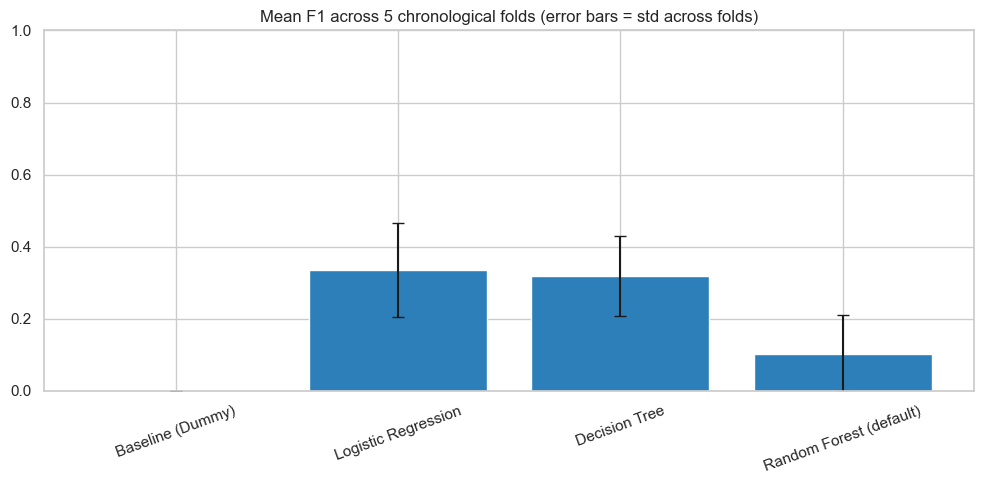

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(cv_summary_df.index, cv_summary_df["f1_mean"], yerr=cv_summary_df["f1_std"], capsize=4, color="#2c7fb8")
ax.set_title(f"Mean F1 across {N_CV_SPLITS} chronological folds (error bars = std across folds)")
ax.set_ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Reading.** Cross-validation changes the single-split picture
substantially.

| model | single-split F1 | CV F1 (mean ± std) |
|---|---|---|
| Logistic Regression | 0.492 | 0.335 ± 0.130 |
| Decision Tree | 0.468 | 0.320 ± 0.111 |
| Random Forest (default) | 0.419 | **0.104 ± 0.107** |
| Baseline | 0.000 | 0.000 ± 0.000 |

Random Forest (default)'s single-split score was not representative —
its fold-averaged F1 collapses to 0.104, far below Logistic Regression
and Decision Tree, with a standard deviation nearly as large as the
mean, meaning it's unstable across time periods, not just weak on
average. Logistic Regression and Decision Tree converge to similar,
lower cross-validated scores (roughly 0.32–0.34) than their single-split
numbers suggested. The single train/validation split flattered every
model to some degree, Random Forest most of all — exactly the kind of
result cross-validation exists to catch.

## 13 — Hyperparameter Tuning: Random Forest

`RandomizedSearchCV` runs over the same chronological folds used in
Section 12 — tuning never sees a random split either. The search covers
`n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`,
`max_features`, and `class_weight`. `class_weight` is restricted to
balanced variants only: Section 05 already established
`class_weight="balanced"` as the imbalance strategy, and letting the
search pick an unweighted option for a marginal score gain would
override that decision.

The search optimizes F1, then the full metric suite is reported for the
winning configuration.

In [19]:
param_distributions = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "class_weight": ["balanced", "balanced_subsample"],
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=30,
    scoring="f1",
    cv=cv_folds,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)
rf_search.fit(X_train, y_train)

print(f"best F1 (mean across {N_CV_SPLITS} folds): {rf_search.best_score_:.3f}")
print("best params:")
rf_search.best_params_

best F1 (mean across 5 folds): 0.326
best params:


{'n_estimators': 100,
 'min_samples_split': 2,
 'min_samples_leaf': 4,
 'max_features': 'log2',
 'max_depth': 5,
 'class_weight': 'balanced_subsample'}

In [20]:
rf_tuned = rf_search.best_estimator_
rf_tuned_val_metrics = evaluate(rf_tuned, X_val, y_val, "Random Forest (tuned)", "validation")
rf_tuned_val_metrics

{'accuracy': 0.4911225760540829,
 'precision': 0.35635496923673854,
 'recall': 0.7050115144204409,
 'f1': 0.4734167893961708,
 'roc_auc': 0.5866964792580036,
 'pr_auc': 0.4023471821334694}

In [21]:
search_results_df = pd.DataFrame(rf_search.cv_results_)[
    ["mean_test_score", "std_test_score", "param_n_estimators", "param_max_depth",
     "param_min_samples_split", "param_min_samples_leaf", "param_max_features", "param_class_weight"]
].sort_values("mean_test_score", ascending=False).head(10).reset_index(drop=True)
search_results_df

,mean_test_score,std_test_score,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features,param_class_weight
0,0.325545,0.143962,100,5,2,4,log2,balanced_subsample
1,0.322543,0.145183,100,5,2,1,log2,balanced_subsample
2,0.321563,0.145069,200,5,10,8,None,balanced
3,0.321141,0.146517,500,5,10,8,None,balanced_subsample
4,0.320678,0.152918,200,5,10,1,log2,balanced
5,0.320164,0.153513,400,5,20,1,log2,balanced_subsample
6,0.319683,0.154847,400,5,5,4,log2,balanced
7,0.316052,0.157143,300,5,10,8,sqrt,balanced_subsample
8,0.283372,0.161392,400,10,20,1,sqrt,balanced
9,0.261386,0.165976,300,10,2,1,log2,balanced_subsample


**Reading.** The search settled on a shallow, heavily regularized
forest (`max_depth=5`, `n_estimators=100`, `min_samples_leaf=4`,
`max_features='log2'`) — consistent with Section 12's finding that a
deeper, unconstrained forest was unstable.

The tuned model's cross-validated F1 (0.326) is now competitive with
Logistic Regression (0.335) and Decision Tree (0.320) — a substantial
recovery from the untuned Random Forest's 0.104. On the validation
split, the tuned model (F1=0.473, ROC-AUC=0.587, PR-AUC=0.402) has the
best ROC-AUC and PR-AUC of all five candidates, even though Logistic
Regression's F1 is nominally still higher. This is the first signal
that Logistic Regression's F1 advantage comes from its precision/recall
imbalance (Section 11), not from stronger overall discrimination —
Section 14 has to weigh both signals.

## 14 — Validation Comparison & Model Selection

All five candidates, validation metrics side by side. Selection uses F1
— consistent with the tuning objective in Section 13, and less
distorted by class imbalance than accuracy, which would favor the
majority-predicting baseline (Section 07).

In [22]:
validation_comparison_df = pd.DataFrame(comparison_records)
validation_comparison_df = validation_comparison_df[validation_comparison_df["split"] == "validation"]
validation_comparison_df = validation_comparison_df.set_index("model")[
    ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
].round(3)
validation_comparison_df = validation_comparison_df.sort_values("f1", ascending=False)
validation_comparison_df

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Logistic Regression,0.347,0.329,0.973,0.492,0.582,0.397
Random Forest (tuned),0.491,0.356,0.705,0.473,0.587,0.402
Decision Tree,0.498,0.356,0.680,0.468,0.564,0.376
Random Forest (default),0.573,0.375,0.474,0.419,0.571,0.391
Baseline (Dummy),0.676,0.000,0.000,0.000,0.500,0.324


In [23]:
best_model_name = validation_comparison_df["f1"].idxmax()
best_model_lookup = {
    "Baseline (Dummy)": (baseline, X_val, X_test),
    "Logistic Regression": (log_reg, X_val_scaled, X_test_scaled),
    "Decision Tree": (dec_tree, X_val, X_test),
    "Random Forest (default)": (rf_default, X_val, X_test),
    "Random Forest (tuned)": (rf_tuned, X_val, X_test),
}
best_model, _, best_X_test = best_model_lookup[best_model_name]
print(f"Selected by validation F1: {best_model_name} (F1={validation_comparison_df.loc[best_model_name, 'f1']:.3f})")
print("Test set has not been touched by this decision -- selection used validation only.")

Selected by validation F1: Logistic Regression (F1=0.492)
Test set has not been touched by this decision -- selection used validation only.


**Reading.** Logistic Regression is selected here on F1 alone. Its
recall/precision imbalance (Section 11) and the tuned Random Forest's
stronger ROC-AUC/PR-AUC (Section 13) are both known at this point but
not factored into the selection rule as defined — how that plays out on
held-out data is the subject of Section 15.

## 15 — Final Chronological Test Evaluation

The only point in this notebook where the test set is used. Test covers
2024–2025 — entirely after every date used for training, validation, or
tuning.

In [24]:
test_metrics = evaluate(best_model, best_X_test, y_test, best_model_name, "test")
print(f"Final test performance -- {best_model_name}:")
test_metrics

Final test performance -- Logistic Regression:


{'accuracy': 0.28072201396414803,
 'precision': 0.278748128609111,
 'recall': 0.9988504278962831,
 'f1': 0.43586099267062395,
 'roc_auc': 0.5480979168673012,
 'pr_auc': 0.3148089007982816}

In [25]:
y_test_pred = best_model.predict(best_X_test)
y_test_proba = best_model.predict_proba(best_X_test)[:, 1]

print(classification_report(y_test, y_test_pred, target_names=["not high_crime_day", "high_crime_day"], zero_division=0))

                    precision    recall  f1-score   support

not high_crime_day       0.90      0.00      0.01     40629
    high_crime_day       0.28      1.00      0.44     15658

          accuracy                           0.28     56287
         macro avg       0.59      0.50      0.22     56287
      weighted avg       0.73      0.28      0.13     56287



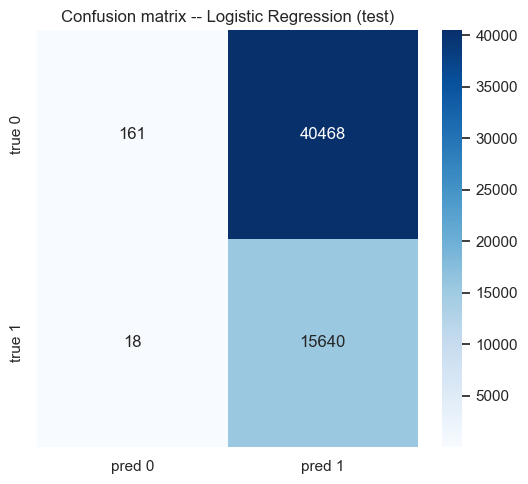

In [26]:
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
ax.set_title(f"Confusion matrix -- {best_model_name} (test)")
plt.tight_layout()
fig.savefig(FIG_DIR / "test_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

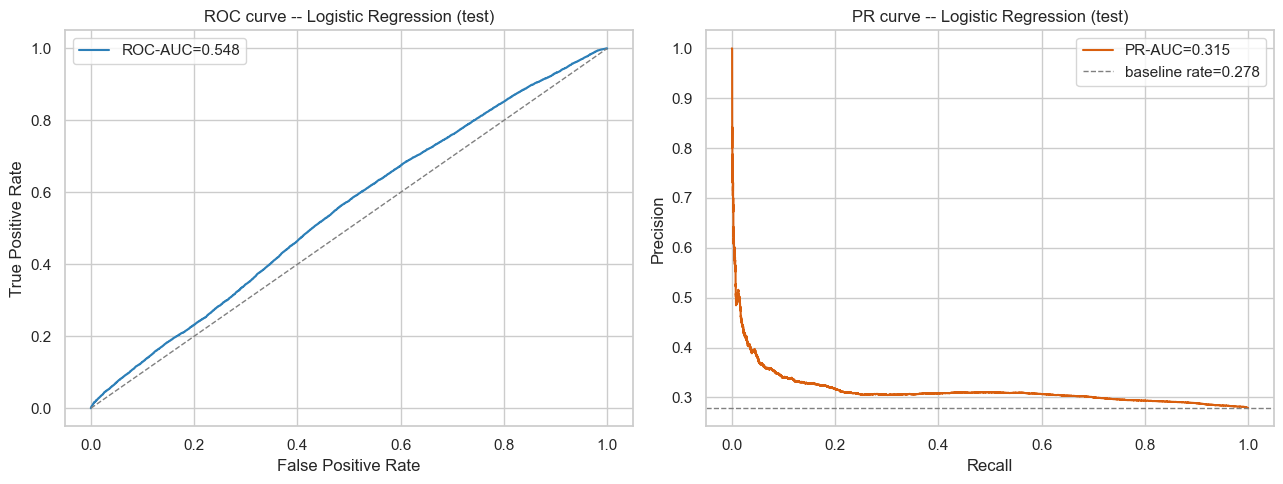

In [27]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_test_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, color="#2c7fb8", label=f"ROC-AUC={test_metrics['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray", lw=1)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title(f"ROC curve -- {best_model_name} (test)")
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, color="#d95f0e", label=f"PR-AUC={test_metrics['pr_auc']:.3f}")
axes[1].axhline(y_test.mean(), ls="--", color="gray", lw=1, label=f"baseline rate={y_test.mean():.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title(f"PR curve -- {best_model_name} (test)")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "test_roc_pr_curves.png", dpi=120, bbox_inches="tight")
plt.show()

**Reading — this is the headline result of the notebook.**

Logistic Regression was selected on validation F1 (0.492, Section 14).
On the test set, it collapses toward a near-constant "always predict
high_crime_day" classifier: recall 0.999 against precision of only
0.279 — almost exactly equal to the test set's own base rate (27.8%,
Section 05). The classification report confirms this directly: the
negative class ("not high_crime_day") has 0.00 recall — the model
predicts positive for essentially all 56,287 test rows. Accuracy fell
to 0.281, below what simply guessing the majority class would give
(roughly 72%). ROC-AUC dropped to 0.548, barely above the 0.5 line a
random model would produce.

In plain terms, Logistic Regression did not learn a genuinely selective
rule on this test period — it leans positive, which scored well on F1
given the class balance, but adds almost no real lift over predicting
"yes" every day. This follows directly from Section 14 selecting on F1
alone, without weighing the precision/recall imbalance already visible
in Section 11 or the stronger, more balanced discrimination the tuned
Random Forest showed in Section 13. See Section 17 for the full
implications.

## 16 — Save Models & Comparison Table

One saved file per algorithm family. Random Forest saves the tuned
estimator from Section 13, not the untuned default from Section 10 —
the tuned version is the one carried forward.

In [28]:
joblib.dump(log_reg, MODELS_DIR / "logistic_regression.joblib")
joblib.dump(dec_tree, MODELS_DIR / "decision_tree.joblib")
joblib.dump(rf_tuned, MODELS_DIR / "random_forest.joblib")
joblib.dump(scaler, MODELS_DIR / "logistic_regression_scaler.joblib")  # required to reuse log_reg correctly later
for f in ["logistic_regression.joblib", "decision_tree.joblib", "random_forest.joblib", "logistic_regression_scaler.joblib"]:
    print(f"saved -> {MODELS_DIR / f}")

saved -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\models\logistic_regression.joblib
saved -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\models\decision_tree.joblib
saved -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\models\random_forest.joblib
saved -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\models\logistic_regression_scaler.joblib


In [29]:
final_comparison_df = pd.DataFrame(comparison_records)
final_comparison_df.to_csv(TABLE_DIR / "model_comparison.csv", index=False)
cv_summary_df.reset_index().to_csv(TABLE_DIR / "cv_summary.csv", index=False)
print(f"saved -> {TABLE_DIR / 'model_comparison.csv'}")
print(f"saved -> {TABLE_DIR / 'cv_summary.csv'}")

saved -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\model_comparison.csv
saved -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\cv_summary.csv


In [30]:
for name, path in [("random_forest.joblib", MODELS_DIR / "random_forest.joblib"),
                    ("decision_tree.joblib", MODELS_DIR / "decision_tree.joblib"),
                    ("logistic_regression.joblib", MODELS_DIR / "logistic_regression.joblib")]:
    reloaded_model = joblib.load(path)
    assert hasattr(reloaded_model, "predict"), f"{name} did not reload as a usable estimator"
print("Round-trip verified: all three saved models reload correctly.")

Round-trip verified: all three saved models reload correctly.


Every saved model reloads and predicts correctly — the files are ready for notebook 09 without re-running training.

## 17 — Findings

**Model comparison**
- Single-split validation ranked Logistic Regression above Decision
  Tree, Random Forest (default), and the baseline on F1 — but this
  ranking did not hold under cross-validation (Section 12): CV F1 was
  0.335±0.130 for Logistic Regression, 0.320±0.111 for Decision Tree,
  and 0.104±0.107 for Random Forest (default) — the single split
  flattered every model, Random Forest by far the most.
- Tuning (Section 13) recovered Random Forest: CV F1 rose to 0.326,
  competitive with the other two, through a much shallower, more
  regularized tree structure than the untuned default.
- On validation, tuned Random Forest had the best ROC-AUC (0.587) and
  PR-AUC (0.402) of all five candidates — stronger overall
  discrimination than Logistic Regression, despite Logistic Regression's
  marginally higher F1 (0.492 vs. 0.473).

**Model selection outcome**
- The selected model, Logistic Regression, degraded sharply on test:
  recall 0.999, precision 0.279 (close to the test set's own 27.8% base
  rate), negative-class recall 0.00, accuracy 0.281 (below the roughly
  72% a majority-class guess would give), ROC-AUC 0.548. It provides
  little real discriminative value on the held-out test period.
- F1 alone was not a sufficient selection criterion here — a model with
  an extreme recall/precision imbalance can win on F1 while performing
  close to a trivial "always predict positive" rule. The tuned Random
  Forest's stronger, more balanced ROC-AUC/PR-AUC profile was available
  before the test set was touched and would have been a better signal
  to weigh alongside F1.

**Class imbalance and accuracy**
- The baseline's validation accuracy (0.676) was the highest of any
  model — every real classifier traded accuracy for recall on the
  minority class. This is precisely why accuracy is reported alongside,
  never instead of, the other metrics: accuracy alone would have
  favored the least useful model here.

**Process checks**
- Every cross-validation fold's training window was verified to end
  before its validation window begins. The test set was evaluated
  exactly once. All three models and both comparison tables were saved
  and confirmed to reload correctly.

Feature importance ranking, per-community-area error analysis, and the
weather ablation comparison are covered in notebook 09.


---

## Overall Conclusion

Four candidates were trained and compared under a strict chronological
design: no random split anywhere, cross-validation folds verified
non-overlapping, and the test set evaluated exactly once, after
selection was already final.

That design caught a real problem. Single-split validation ranked
Logistic Regression on top, but cross-validation showed that ranking
wasn't representative — Random Forest (default) in particular collapsed
from F1=0.419 on the single split to F1=0.104±0.107 across five
chronological folds. Tuning recovered Random Forest to a competitive,
more stable configuration with the best ROC-AUC and PR-AUC of any model
on validation.

Model selection still followed the pre-defined rule — validation F1 —
and picked Logistic Regression. On test, that choice did not hold up:
the model predicts positive for nearly every row (recall 0.999,
negative-class recall 0.00), with precision barely above the test set's
own base rate — close to a trivial "always predict high_crime_day" rule
rather than a genuinely discriminative model. This is reported directly,
because a methodology that only surfaces convenient results isn't doing
its job.

**Practical takeaway.** The tuned Random Forest — saved regardless of
the F1-based selection outcome — is the more defensible model to carry
into feature importance and error analysis, given its stronger and more
stable discrimination across both single-split and cross-validated
evidence. Any future re-run of model selection should weigh ROC-AUC and
PR-AUC alongside F1, not F1 in isolation.

**Handed to notebook 09.** All three saved models, `model_comparison.csv`,
and `cv_summary.csv`. Notebook 09 should treat Random Forest as the
primary subject for feature importance and error analysis, while still
reporting Logistic Regression's test-set behavior as a documented,
cautionary result from this stage.
